In [7]:
# IMPORT LIBRARIES & LOAD DATASET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r"C:\Users\Hamza Ali\Downloads\Dataset for Data Analytics (1).xlsx")

# Display first 5 rows
print(df.head())


     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [8]:
# DATASET INFORMATION
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Shape: (1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [10]:
# MISSING VALUES & DUPLICATES
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())


Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicates:
0


In [11]:
# DESCRIPTIVE STATISTICS

print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [12]:
# PRODUCT WISE REVENUE ANALYSIS
product_revenue = df.groupby("Product")["TotalPrice"].sum()

print("\nRevenue by Product")
print(product_revenue)


Revenue by Product
Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64


In [13]:
# ORDER STATUS ANALYSIS
print("\nOrder Status Distribution")
print(df["OrderStatus"].value_counts())


Order Status Distribution
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [14]:
# MONTHLY REVENUE ANALYSIS
df["Month"] = df["Date"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["TotalPrice"].sum()

print("\nMonthly Revenue")
print(monthly_revenue)



Monthly Revenue
Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


In [15]:
# CORRELATION ANALYSIS

print("\nCorrelation Matrix")

print(
    df[
        ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    ].corr()
)



Correlation Matrix
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


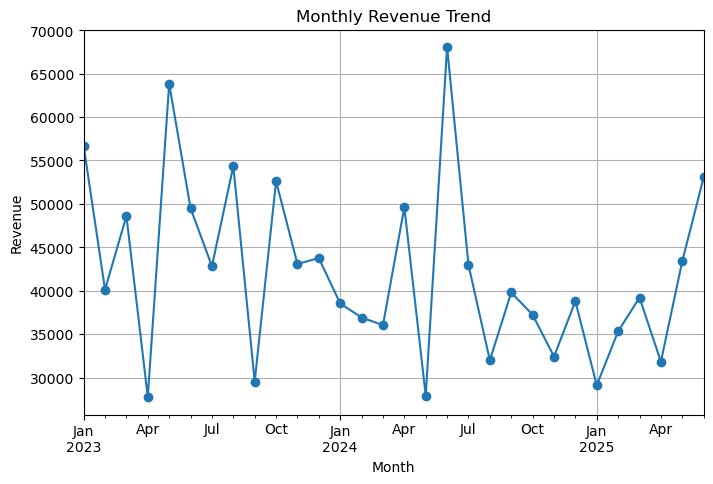

In [16]:
# MONTHLY REVENUE TREND CHART
monthly_revenue.plot(
    kind="line",
    figsize=(8,5),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

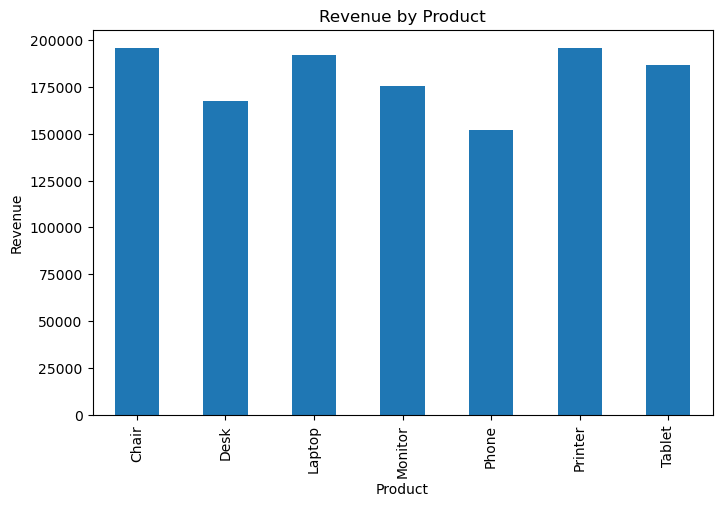

In [17]:
# PRODUCT REVENUE BAR CHART
product_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()


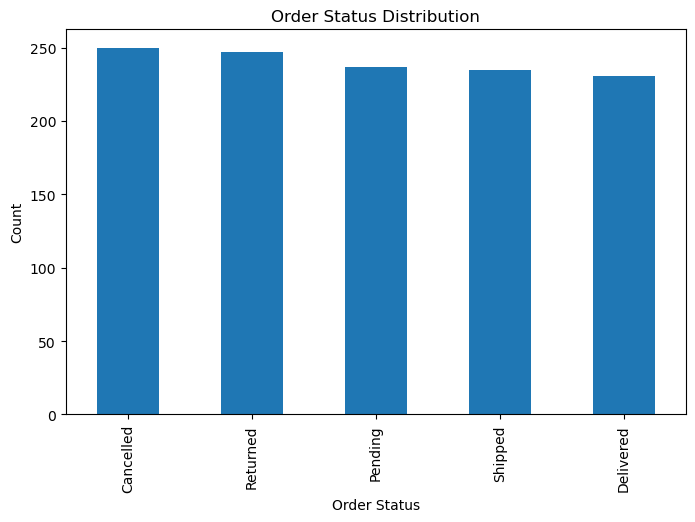

In [19]:
# ORDER STATUS DISTRIBUTION CHART
df["OrderStatus"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

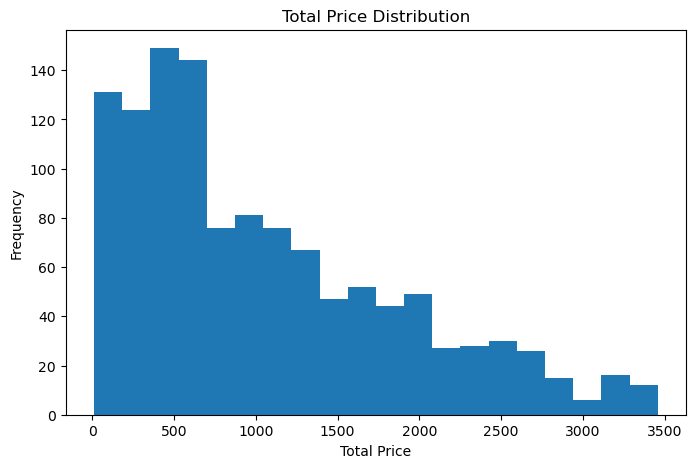

In [20]:
# TOTAL PRICE DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(
    df["TotalPrice"],
    bins=20
)

plt.title("Total Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

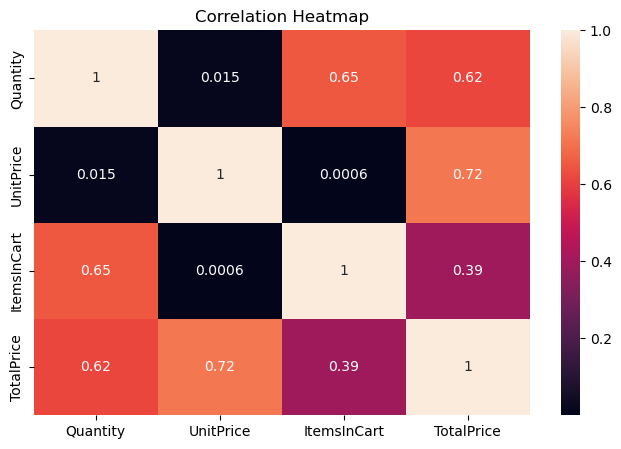

In [21]:
# CORRELATION HEATMAP
plt.figure(figsize=(8,5))

sns.heatmap(
    df[
        ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    ].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
# PROJECT COMPLETION MESSAGE
print("\nEDA Completed Successfully")


EDA Completed Successfully
